<a href="https://colab.research.google.com/github/4RY4N-XD/PyTorch_Fundamentals/blob/main/01_PyTorch_Fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PyTorch Workflow

In [ ]:
what_were_covering = { 1:"data(prepare and load)",
                       2: "build model",
                       3: "fitting the model to data(training)",
                       4: "making predictions and evaluating a model(inference)",
                       5: "saving and loading a model",
                       6: "putting it al together"

}

In [ ]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.10.0+cpu'

## 1. Data (Preparing and loading)

Data can be almost anything... in machine learning

* Excel spreadsheet
* Images
* Videos
* Audio
* DNA
* Text

Machine learning is a game of two parts:
1. Get data into a numerical representation
2. Build a model to learn patterns in that numerical representation


To showcase this, let's create some *known* data using the linear regression formula.
We'll use a linear regression formula to make a straight line with known **parameters**.

In [ ]:
# Create *known* parameters

weight = 0.7
bias = 0.3

#Create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias #actual output not a predicted one

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
len(X), len(y)

(50, 50)

### Splitting data into training and test sets (one of the most important concepts in machine learning in general)

Let's create a training and test set with our data.

In [ ]:
#Create a train/test split
import sklearn
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

len(X_train), len(X_test), len(y_train), len(y_test)

(40, 10, 40, 10)

How might we better visualize our data?

This is where the data explorer's motto comes in!

"Visualize, visualize, visualize!"

In [ ]:
import matplotlib.pyplot as plt

In [ ]:

def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions = None):

#Plots training data, test data and compare predictions.

  plt.figure(figsize=(10, 7))

#Plot training data in blue
  plt.scatter(train_data, train_labels, c = "b", s = 4,
              label = "Training data")

#Plot test data in green
  plt.scatter(test_data, test_labels, c = "g", s= 4, label = "Testing data")

#Are there predictions?
  if predictions is not None:
    #Plot the predictions if they exist
    plt.scatter(test_data, predictions, c = "r", s = 4, label = "Predictions")
#Show the legend
  plt.legend(prop = {"size" : 14})

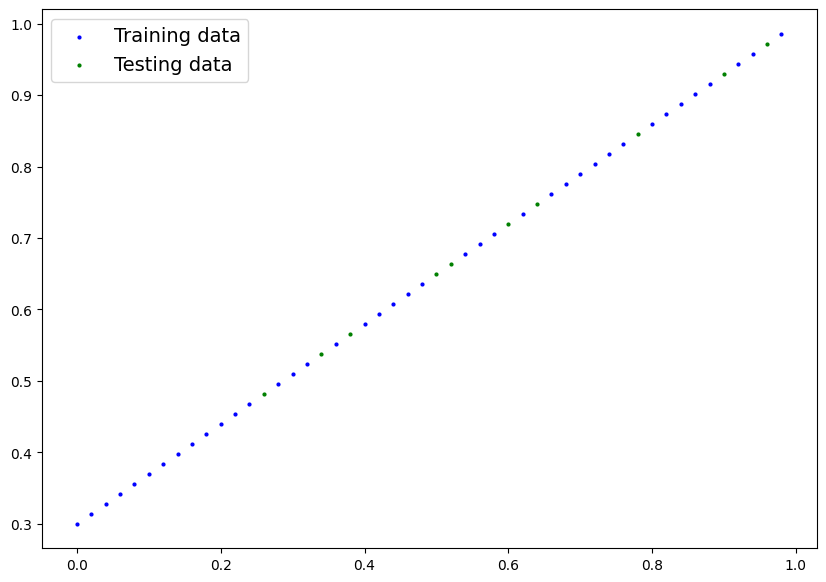

In [ ]:
plot_predictions()

## 2. Build module

Our first PyTorch model!

What our model does:
* Start with random values (weight & bias)
* Look at training data and adjsut the random values to better represent (or get closer to) the ideal values (the weight & bias values we used to create the data)

How does it do so?

Through two main algorithms:
1. Gradient descent
2. Backpropagation

In [ ]:
# Create linear regression model class
from torch import nn
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch inherits from nn.Module
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1, requires_grad= True, dtype= torch.float))

    self.bias = nn.Parameter(torch.randn(1, requires_grad= True, dtype= torch.float))

    # Forword method to define the computation in the model
  def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data
    return self.weights * x + self.bias #this is linear regression formula


### PyTorch model building essentials

* torch.nn - contains all of the building blocks for computational graphs (a neural network can be computational graph)
* torch.nn.Parameter - what parameter should our model try and learn from torch.nn will set these for us
* torch.nn.Module - The base class for all neural network modules, if you subclass it, you should overwrite forward()
* torch.optim - this is where the optimizers in PyTorch live, they will help with gradient descent
* def forward() - All nn.Module subclasses require you to overwrite forward(), this method defines what happens in the forward computation

### Checking the contents of our PyTorch model

Now we've created a model, let's see what's inside...
So we can check our model parameters or what's inside our model using `.parameters()`

In [ ]:
# Create a random seed
torch.manual_seed(42)

#Create an instance of the model (this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

#Check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
#List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making prediction using `torch.inference_mode()`

To check our model's predictive power, let's see how well it predicts `y_test` based on `x_test`.


When we pass data through our model, it's going to run it through the `forward()` method.


In [ ]:
y_preds = model_0(X_test)
y_preds #But it is not dealing with gradient so we use torch.inference_mode()

tensor([[0.2163],
        [0.3914],
        [0.3308],
        [0.4318],
        [0.2433],
        [0.4520],
        [0.3039],
        [0.2972],
        [0.3443],
        [0.2568]], grad_fn=<AddBackward0>)

In [ ]:
# Make predictions with model
with torch.inference_mode():
  y_preds = model_0(X_test)

# # You can also do something similar with torch.no_grad(), however, torch.inference_mode() is preferred
# with torch.no_grad():
#   y_preds = model_0(X_test)
y_preds

tensor([[0.2163],
        [0.3914],
        [0.3308],
        [0.4318],
        [0.2433],
        [0.4520],
        [0.3039],
        [0.2972],
        [0.3443],
        [0.2568]])

In [ ]:
y_test

tensor([[0.4820],
        [0.8460],
        [0.7200],
        [0.9300],
        [0.5380],
        [0.9720],
        [0.6640],
        [0.6500],
        [0.7480],
        [0.5660]])

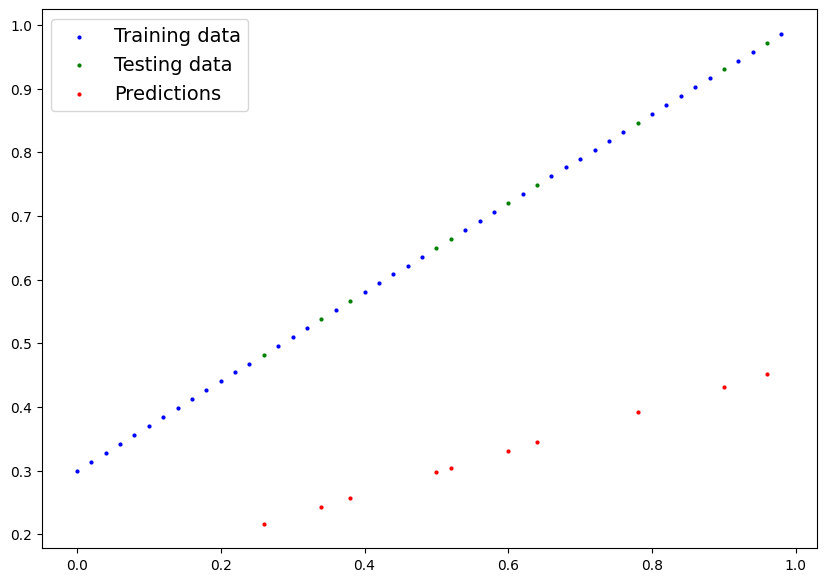

In [ ]:
plot_predictions(predictions=y_preds)

## 3. Train model

The whole idea of training is for a model to move from some *unknown* parameters (these may be random) to some *known* parameters.

Or in other words from a poor representation of the data to a better representation of the data.

One way to measure how poor or how wrong your models predictions are is to use a loss function.

* NOTE: Losss function may also be called cost function or criterion is different areas.

* **Loss function:** A function to measure how wrong your model's predictions are to the ideal outputs, lower is better.

* **Optimizer:** Takes into account the loss of a model and adjusts the model's parameters (e.g. weight and bias in our case) to improve the loss function.

    * Inside the optimizer you'll often have to set two parameters:
        * `params` - the model parameters you'd like to optimize, for example `params= model_0.parameters()`
        * `lr`(learning rate) - the learning rate is a hyperparameter that defines how big/small the optimizer changes the parameters with each step (a small `lr` results in small changes, a large `lr` results in large changes)

And specifically for PyTorch, we need:
* A training loop
* A testing loop


In [ ]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
#Check out our model's parameters (a parameters is a value that the model sets itself)
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
#Setup a loss function

loss_fn = nn.L1Loss() #MAE

#Setup an optimizer (stochastic gradient descent)

optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr = 0.01) #lr = learning rate = possibly the most important hyperparameter you can set

**Q:** Which loss function and optimizer should I use?

**A:** This will be problem specific. But with experience, you'll get an idea of what works and what doesn't with your particular problem set.

For example,

for regression - loss function = `nn.L1Loss()` and optimizer = `torch.optim.SGD()`

for classification- loss function = `nn.BCELoss()` (binary cross entropy loss)

### Building a training loop (and a testing loop) in PyTorch

A couple of things we need in a training loop:

0. Loop through the data and do...
1. Forward pass (this involves data moving through our model's `forward()` functions) to make predictions on data - also called forward propagation
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backwards thorugh network to calculate the gradients of each of the parameters of our model with respect to the loss (**backpropagation**)
5. Optimizer step - use the optimizer to adjsut our model's parameters to try and improve the loss (**gradient descent**)

In [ ]:
model_0.state_dict()


OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
torch.manual_seed(42)

#Set the number of epochs (how many times the model will loop through the data)
# An epoch is one loop through the data... (this is a hyperparameter because we've set it overselves)
epochs = 200

#Track different values
epoch_count = []
loss_values = []
test_loss_values = []


### Training
#0. Loop through the data
for epoch in range(epochs):
  #Set the model to training mode
  model_0.train() #train mode in PyTorch sets all parameters that require gradients to require gradients

  #1. Forward pass
  y_pred = model_0(X_train)

  #2. Calculate the loss
  loss = loss_fn(y_pred, y_train)
  print(loss)

  #3. Optimizer zero grad
  optimizer.zero_grad()

  #4. Perform backpropagation on the loss with respect to the parameters of the model
  loss.backward()

  #5. Optimizer step (perform gradient descent)
  optimizer.step() #by default how the optimizer changes will acculumate through the loop so... we ahve to zero them above in step 3 for the next iteration of the loop

  ###Testing
  model_0.eval() # turns off different settings in the model not needing for evaluation/testing (dropout/batch norm layers)

  with torch.inference_mode(): #turns of gradient tracking & a couple more things behind the scene
    # 1. Do the Forward pass on test data
    test_pred = model_0(X_test)

    #2. Calculate the loss on test data
    test_loss = loss_fn(test_pred, y_test)

  #Print out what's happening
  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")
    # Print out model state_dict()
    print(model_0.state_dict())



tensor(0.3403, grad_fn=<MeanBackward0>)
Epoch: 0 | Loss: 0.340311199426651 | Test Loss: 0.3720795214176178
OrderedDict({'weights': tensor([0.3413]), 'bias': tensor([0.1388])})
tensor(0.3281, grad_fn=<MeanBackward0>)
tensor(0.3160, grad_fn=<MeanBackward0>)
tensor(0.3038, grad_fn=<MeanBackward0>)
tensor(0.2916, grad_fn=<MeanBackward0>)
tensor(0.2795, grad_fn=<MeanBackward0>)
tensor(0.2673, grad_fn=<MeanBackward0>)
tensor(0.2551, grad_fn=<MeanBackward0>)
tensor(0.2430, grad_fn=<MeanBackward0>)
tensor(0.2308, grad_fn=<MeanBackward0>)
tensor(0.2186, grad_fn=<MeanBackward0>)
Epoch: 10 | Loss: 0.21864214539527893 | Test Loss: 0.24470801651477814
OrderedDict({'weights': tensor([0.3879]), 'bias': tensor([0.2388])})
tensor(0.2065, grad_fn=<MeanBackward0>)
tensor(0.1943, grad_fn=<MeanBackward0>)
tensor(0.1821, grad_fn=<MeanBackward0>)
tensor(0.1700, grad_fn=<MeanBackward0>)
tensor(0.1578, grad_fn=<MeanBackward0>)
tensor(0.1456, grad_fn=<MeanBackward0>)
tensor(0.1335, grad_fn=<MeanBackward0>)
tens

In [ ]:
import numpy as np

np.array(torch.tensor(loss_values).detach().cpu().numpy()),
test_loss_values

[tensor(0.3721),
 tensor(0.2447),
 tensor(0.1229),
 tensor(0.0607),
 tensor(0.0413),
 tensor(0.0340),
 tensor(0.0296),
 tensor(0.0252),
 tensor(0.0208),
 tensor(0.0164),
 tensor(0.0121),
 tensor(0.0079),
 tensor(0.0040),
 tensor(0.0011),
 tensor(0.0011),
 tensor(0.0011),
 tensor(0.0011),
 tensor(0.0011),
 tensor(0.0011),
 tensor(0.0011)]

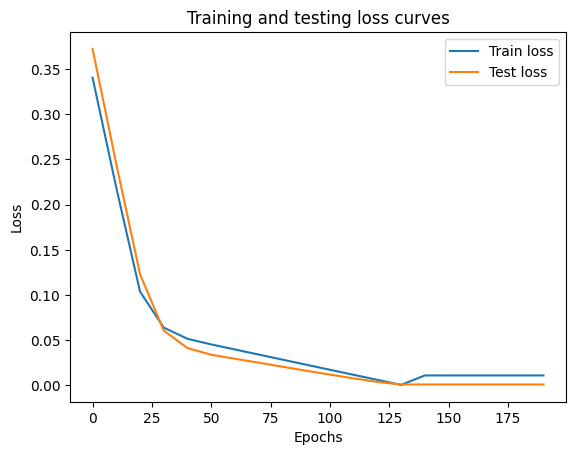

In [ ]:
#Plot the loss curve
plt.plot(epoch_count, np.array(torch.tensor(loss_values).detach().cpu().numpy()), label = "Train loss") #we need to change it into array from tensor, because plt doesn't not work on tensor
plt.plot(epoch_count, np.array(torch.tensor(test_loss_values).detach().cpu().numpy()), label = "Test loss")
plt.title("Training and testing loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

In [ ]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.7039])), ('bias', tensor([0.3093]))])

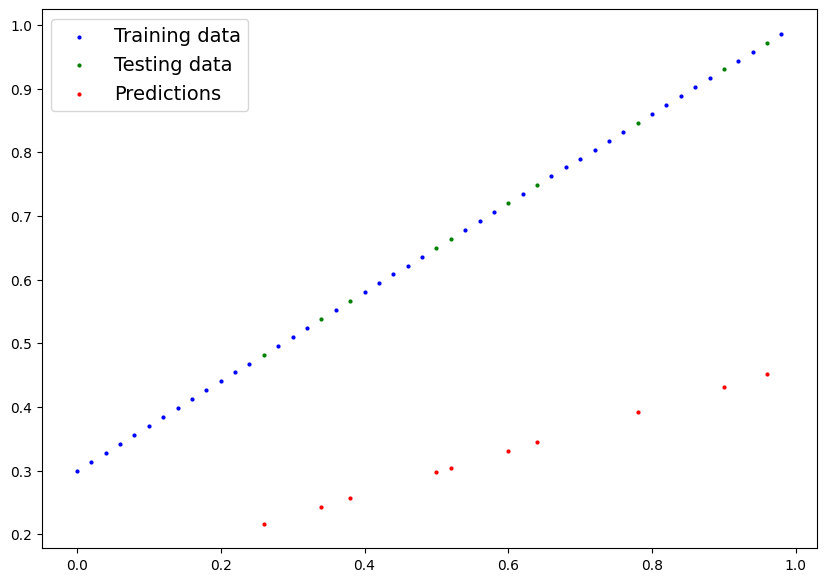

In [ ]:
plot_predictions(predictions=y_preds)

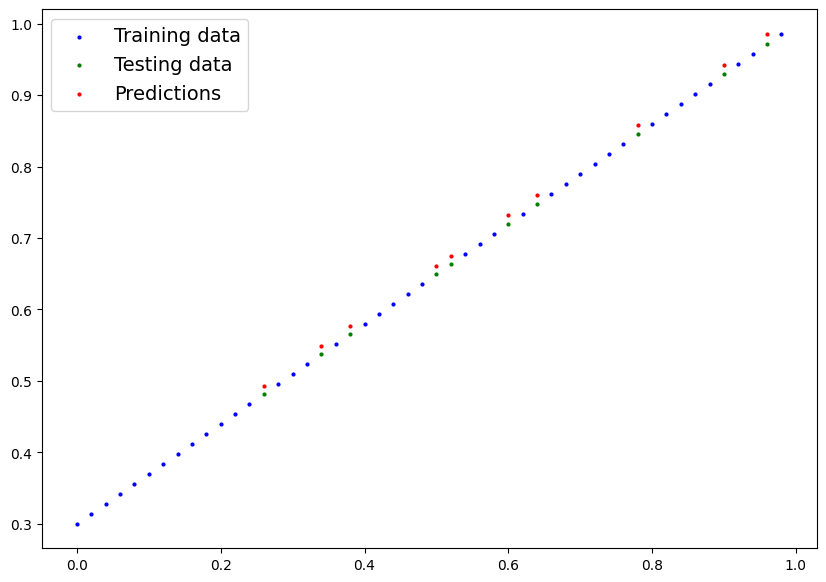

In [ ]:
plot_predictions(predictions= y_preds_new)

##Saving a model in PyTorch

There are three main methods you should know about for saving and loading models in PyTorch.

1. `torch.save()` - allows you save a PyTorch object in Python's pickle format
2. `torch.load()` - allows you to load a saved PyTorch object
3. `torch.nn.Module.load_state_dict()` - this allows to load a model's saved state dictionary

In [ ]:
# Saving our PyTorch model
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

#2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

#3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj = model_0.state_dict(),
           f = MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_0.pth


In [ ]:
!ls -l models

total 4
-rw-r--r-- 1 root root 2117 Apr  9 13:52 01_pytorch_workflow_model_0.pth


## Loading a PyTorch model

Since we saved our model's `state_dict()` rather that the entire model, we'll create a new instance of our model class and load the save `state_dict()` into that.

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.7039])), ('bias', tensor([0.3093]))])

In [ ]:
#To load in a saved_dict we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

# Load the saved state_dict of model_0 (this will update the new instance with updated parameters)
loaded_model_0.load_state_dict(torch.load(f = MODEL_SAVE_PATH))

<All keys matched successfully>

In [ ]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.7039])), ('bias', tensor([0.3093]))])

In [ ]:
#Make some predictions with our loaded model

loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.4923],
        [0.8584],
        [0.7317],
        [0.9428],
        [0.5486],
        [0.9851],
        [0.6754],
        [0.6613],
        [0.7598],
        [0.5768]])

In [ ]:
model_0.eval()
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[0.4923],
        [0.8584],
        [0.7317],
        [0.9428],
        [0.5486],
        [0.9851],
        [0.6754],
        [0.6613],
        [0.7598],
        [0.5768]])

In [ ]:
#Compare loaded model preds with original model preds
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## 6. Putting it all together

Let's go back through the steps above and see it all in one place.

In [1]:
# Import PyTorch and Matplotlib
import torch
from torch import nn
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.10.0+cpu'

Create a device-agnostic code

This means if we've got access to a GPU, our code will use it
Otherwise the code will default use of CPU

In [2]:
#Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'